# WASP2026 draft: plot-type accuracy by figure category

A single heatmap panel. It replaces the three-panel "counting and types"
figure this notebook used to build from the `jcdl_followup` run; that code has
been removed, and is in git history if it is ever wanted back.

* **y-axis** -- the low-tier models in the run directory below
* **x-axis** -- what the figure actually is: contour, sky image from a gaussian
  mixture ("fake"), or sky image from a real survey cutout
* **cell value** -- accuracy of the *plot type* question, the same binary
  comparison the original panel uses (exact string match after lowercasing and
  stripping spaces), averaged over the figures in that category

The x-axis is the reason this needs its own parsing rather than the pipeline
above. The plot-type question's ground truth is only `contour` or
`image of the sky` -- it cannot tell a synthetic sky from a real one. The
three-way category comes from the figure's own data (`plot0.distribution` in
the qa json), not from any answer.

These cells are self-contained -- they do not use `parse_lmm_output_utils` or
`results_plotting_utils`, which are not part of this repo.


In [1]:
# ======================== CONFIG ========================
# One row of the figure per run: (row label, directory of per-model pickles).
# All three cover the SAME 150 figures, so the rows differ only by how the page
# was treated before it was sent.
runs = [
    ('original',      '~/astro_sky_image_vqa/LMM_outputs_n150/'),
    ('archive',       '~/astro_sky_image_vqa/LMM_outputs_n150_archive/'),
    ('archive-light', '~/astro_sky_image_vqa/LMM_outputs_n150_archive_light/'),
]

# The full-strength 'archive' aging may not make the paper -- this drops that
# row without touching anything else.
show_archive = False

# The released VQA jsons -- needed for each figure's true category.
qa_jsons_dir = '~/astro_sky_image_vqa/VQA_full/qa_jsons/'

fig_out_dir = '~/Dropbox/WASP2026/paper_figures/'
fig_name    = 'plot_type_by_category.pdf'

# model subdirectory -> display name, in the order they should appear top to
# bottom.  Same low tier as low_dirs_to_use in the original figure.
model_names = {
    'chatgpt_api':  'GPT',
    'gemini':       'Gemini',
    'claude_haiku': 'Claude',
}

# The plot-type question is asked twice: once offering [contour, image of the
# sky] as a list, once open-ended.  The original figure scores the list variant
# (question_types[0] has 'use list': True).  The open-ended one scores ~0 for
# every model -- they answer things like "Astronomical survey image", which
# never matches the ground-truth string -- so it measures phrasing, not vision.
use_list_variant = True

# x-axis order and labels
category_order  = ['contour', 'sky-gmm', 'sky-real']
category_labels = {'contour':  'contour',
                   'sky-gmm':  'sky image\n(synth data)',
                   'sky-real': 'sky image\n(real data)'}

show_counts_in_xlabel = True    # append (n=...) to each column label

# Rows are packed close together and only the BOTTOM one keeps its x-axis
# labels, since all rows share the same three categories.
row_gap      = 0.06     # vertical space between rows, as a fraction of row height
row_height_in = 2.2     # height of one row
fig_width_in  = 7.6


In [2]:
import os, json, glob, pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# run paths are expanded per row in the PARSE cell
qa_jsons_dir = os.path.expanduser(qa_jsons_dir)
fig_out_dir  = os.path.expanduser(fig_out_dir)
os.makedirs(fig_out_dir, exist_ok=True)


def json_objects(s):
    """Every top-level JSON object in `s`, in order, using the real decoder."""
    if not isinstance(s, str):
        return []
    dec, out, i = json.JSONDecoder(), [], 0
    while True:
        i = s.find('{', i)
        if i < 0:
            break
        try:
            obj, end = dec.raw_decode(s, i)
        except ValueError:
            i += 1
            continue
        if isinstance(obj, dict):
            out.append(obj)
        i = end
    return out


def recovered_answer(entry):
    """
    The model's answer to one question.

    `entry['Response']` cannot be used directly: the models reply with two
    fenced json blocks (answer, then explanation) and parse_qa keeps only the
    last, so Response is usually the explanation alone.  Merging every object
    found in `raw answer` recovers the answer; the first non-explanation key is
    it, whatever the model chose to call it ("plot_types", "plot type", ...).
    """
    merged = {}
    for o in json_objects(entry.get('raw answer')):
        merged.update(o)
    resp = entry.get('Response')
    if isinstance(resp, dict):
        for k, v in resp.items():
            merged.setdefault(k, v)
    for k, v in merged.items():
        if k.lower().strip() != 'explanation':
            return v
    return None


def normalise(x):
    """Match the original panel's comparison: lowercase, spaces stripped."""
    return str(x).lower().replace(' ', '').replace('_', '').strip()


_cat_cache = {}

def figure_category(vqa_id):
    """contour / sky-gmm / sky-real, from the figure's own data."""
    if vqa_id in _cat_cache:
        return _cat_cache[vqa_id]
    with open(os.path.join(qa_jsons_dir, vqa_id + '_qa.json')) as f:
        d = json.loads(json.load(f))
    types, dists = set(), set()
    for k, v in d.items():
        if k.startswith('plot'):
            types.add(v.get('type'))
            dists.add(v.get('distribution'))
    if types == {'contour'}:
        c = 'contour'
    elif types == {'image of the sky'}:
        c = 'sky-gmm' if dists == {'gmm'} else 'sky-real'
    else:
        c = 'other'
    _cat_cache[vqa_id] = c
    return c


In [3]:
# ======================== PARSE ========================
# One row of the figure per run; all three cover the same 150 figures, so a
# difference between rows is a difference in how the page was degraded.
active_runs = [(lab, d) for lab, d in runs if show_archive or lab != 'archive']

rows = []
for run_label, run_path in active_runs:
    run_path = os.path.expanduser(run_path)
    for mdir, mname in model_names.items():
        pkls = sorted(glob.glob(os.path.join(run_path, mdir, '*_qa.pickle')))
        if not pkls:
            print('[WARN] no pickles in', os.path.join(run_path, mdir))
            continue
        for fp in pkls:
            vqa_id = os.path.basename(fp).removesuffix('_qa.pickle')
            with open(fp, 'rb') as f:
                payload = pickle.load(f)
            qa_list = payload[0] if isinstance(payload, (list, tuple)) else payload
            model_id = (payload[1] if isinstance(payload, (list, tuple)) and len(payload) > 1
                        else mdir)

            for e in qa_list:
                q = (e.get('question') or '').lower()
                if 'plot type' not in q:
                    continue
                # the two variants differ only by the multiple-choice list in context
                offers_list = 'please choose' in (e.get('context') or '').lower()
                if offers_list != use_list_variant:
                    continue

                truth = list(e['A'].values())[0]
                if isinstance(truth, list):
                    truth = truth[0] if truth else ''
                answer = recovered_answer(e)
                if isinstance(answer, list):
                    answer = answer[0] if answer else ''
                # nothing usable came back: no json block, or only an
                # explanation.  Counted as wrong below, but tracked separately --
                # a model that cannot be parsed is failing differently from one
                # that answers the wrong category.
                parsed = answer is not None and str(answer).strip() != ''

                rows.append({'run': run_label,
                             'model': mname, 'model_id': model_id, 'vqa_id': vqa_id,
                             'category': figure_category(vqa_id),
                             'truth': truth, 'answer': answer, 'parsed': parsed,
                             'correct': int(normalise(truth) == normalise(answer))})

dfcat = pd.DataFrame(rows)
print('rows to plot:', ', '.join(lab for lab, _ in active_runs))
print()
for lab, _ in active_runs:
    sel = dfcat[dfcat['run'] == lab]
    print('  %-14s %5d answers, %3d figures, %d models'
          % (lab, len(sel), sel['vqa_id'].nunique(), sel['model'].nunique()))
print()
print('figures per category (per run):')
print(dfcat.groupby(['run', 'category'])['vqa_id'].nunique().unstack().to_string())

print()
print('UNPARSEABLE answers (no usable json came back; scored as wrong):')
unp = (dfcat.assign(unparseable=~dfcat['parsed'])
            .groupby(['run', 'model'])['unparseable'].agg(['sum', 'count']))
unp['pct'] = 100.0 * unp['sum'] / unp['count']
unp.columns = ['unparseable', 'answers', '%']
print(unp.to_string(float_format=lambda v: '%.1f' % v))
if unp['unparseable'].sum() == 0:
    print('   (none)')
dfcat.head()


rows to plot: original, archive-light

  original         450 answers, 150 figures, 3 models
  archive-light    450 answers, 150 figures, 3 models

figures per category (per run):
category       contour  sky-gmm  sky-real
run                                      
archive-light       51       48        51
original            50       50        50

UNPARSEABLE answers (no usable json came back; scored as wrong):
                      unparseable  answers   %
run           model                           
archive-light Claude            0      150 0.0
              GPT               0      150 0.0
              Gemini            0      150 0.0
original      Claude            0      150 0.0
              GPT               0      150 0.0
              Gemini            0      150 0.0
   (none)


,run,model,model_id,vqa_id,category,truth,answer,parsed,correct
0,original,GPT,gpt-5.4-nano-2026-03-17,vqa_000001,sky-gmm,image of the sky,contour,True,0
1,original,GPT,gpt-5.4-nano-2026-03-17,vqa_000002,sky-real,image of the sky,image of the sky,True,1
2,original,GPT,gpt-5.4-nano-2026-03-17,vqa_000003,sky-real,image of the sky,image of the sky,True,1
3,original,GPT,gpt-5.4-nano-2026-03-17,vqa_000004,sky-real,image of the sky,contour,True,0
4,original,GPT,gpt-5.4-nano-2026-03-17,vqa_000005,sky-real,image of the sky,image of the sky,True,1


In [4]:
dfcat[dfcat['model']=='Claude']

,run,model,model_id,vqa_id,category,truth,answer,parsed,correct
300,original,Claude,claude-haiku-4-5,vqa_000001,sky-gmm,image of the sky,image of the sky,True,1
301,original,Claude,claude-haiku-4-5,vqa_000002,sky-real,image of the sky,image of the sky,True,1
302,original,Claude,claude-haiku-4-5,vqa_000003,sky-real,image of the sky,image of the sky,True,1
303,original,Claude,claude-haiku-4-5,vqa_000004,sky-real,image of the sky,image of the sky,True,1
304,original,Claude,claude-haiku-4-5,vqa_000005,sky-real,image of the sky,image of the sky,True,1
...,...,...,...,...,...,...,...,...,...
895,archive-light,Claude,claude-haiku-4-5,vqa_000164,sky-gmm,image of the sky,image of the sky,True,1
896,archive-light,Claude,claude-haiku-4-5,vqa_000166,sky-gmm,image of the sky,image of the sky,True,1
897,archive-light,Claude,claude-haiku-4-5,vqa_000167,contour,image of the sky,image of the sky,True,1
898,archive-light,Claude,claude-haiku-4-5,vqa_000169,contour,image of the sky,image of the sky,True,1


wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/plot_type_by_category.pdf

--- original ---
category  contour  sky-gmm  sky-real
model                               
GPT          66.0     52.0      44.0
Gemini       80.0    100.0     100.0
Claude       18.0    100.0     100.0
--- archive-light ---
category  contour  sky-gmm  sky-real
model                               
GPT          60.8     70.8      68.6
Gemini       94.1     89.6      90.2
Claude       76.5     64.6      70.6


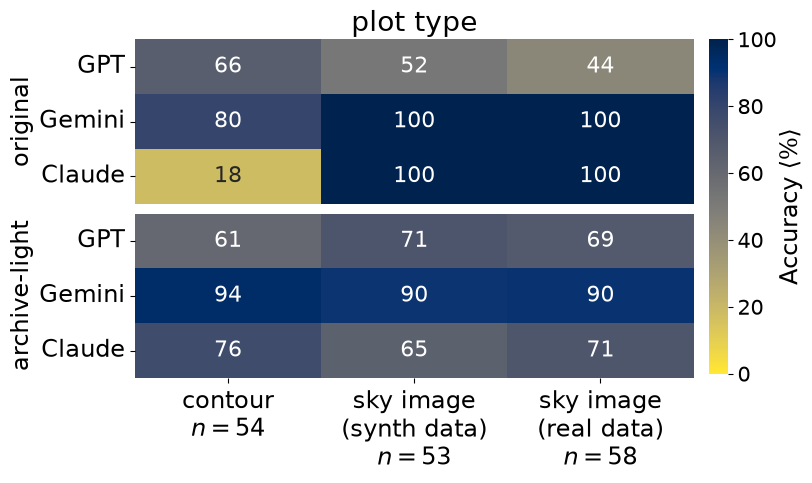

In [5]:
# ======================== PLOT ========================
fontsize           = 20
tick_fontsize      = 17
barfontsize        = 17
cbar_tick_fontsize = 15
annot_fontsize     = 16
annot_fmt          = '.0f'
cmap               = 'cividis_r'
barpad             = 2
rowlabel_fontsize  = 17
acctag             = r'Accuracy $\mathrm{\langle \% \rangle}$'

row_labels = [lab for lab, _ in active_runs]
nrows = len(row_labels)

# one pivot per row, on a fixed model x category grid so every row lines up
pivots = {}
for lab in row_labels:
    sel = dfcat[dfcat['run'] == lab]
    pv = (sel.pivot_table(index='model', columns='category',
                          values='correct', aggfunc='mean') * 100)
    pv = pv.reindex([v for v in model_names.values() if v in pv.index])
    pv = pv.reindex(columns=[c for c in category_order if c in pv.columns])
    pivots[lab] = pv

counts = dfcat.groupby('category')['vqa_id'].nunique()
xlabels = []
for c in pivots[row_labels[0]].columns:
    lab = category_labels.get(c, c)
    if show_counts_in_xlabel:
        lab += '\n$n=%d$' % counts.get(c, 0)
    xlabels.append(lab)

fig, axes = plt.subplots(nrows, 1,
                         figsize=(fig_width_in, row_height_in * nrows),
                         gridspec_kw={'hspace': row_gap,
                                      'right': 0.86})
axes = np.atleast_1d(axes)

# one shared colorbar for the whole figure rather than one per row: the scale is
# the same everywhere, and three of them would eat the width the rows need
cbar_ax = fig.add_axes([0.88, 0.12, 0.025, 0.76])

for i, (ax, lab) in enumerate(zip(axes, row_labels)):
    last = (i == nrows - 1)
    sns.heatmap(pivots[lab], annot=True, fmt=annot_fmt, cmap=cmap,
                vmin=0, vmax=100, ax=ax,
                annot_kws={'size': annot_fontsize},
                cbar=(i == 0), cbar_ax=(cbar_ax if i == 0 else None))
    ax.set_xlabel('')
    # the row label goes on the left, outside the model names
    ax.set_ylabel(lab, fontsize=rowlabel_fontsize)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')
    # x tick labels only on the bottom row -- all rows share the same categories
    if last:
        ax.set_xticklabels(xlabels, fontsize=tick_fontsize)
    else:
        ax.set_xticklabels([])
        ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

axes[0].set_title('plot type', fontsize=fontsize)

cbar_ax.set_ylabel(acctag, fontsize=barfontsize, labelpad=barpad)
cbar_ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))
cbar_ax.tick_params(labelsize=cbar_tick_fontsize)

out_path = os.path.join(fig_out_dir, fig_name)
fig.savefig(out_path, bbox_inches='tight')
print('wrote', out_path)
print()
for lab in row_labels:
    print('--- %s ---' % lab)
    print(pivots[lab].round(1).to_string())
